In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
def draw_decision_tree(model, feature_names):
    dot_buf = io.StringIO()
    export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
    graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
    image = graph.create_png()
    return Image(image)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_decision_regions(X, y, model, title):
    species = ['setosa', 'versicolor', 'virginica']
    resolution = 0.01
    markers = ('s', '^', 'o')
    colors = ('red', 'blue', 'lightgreen')
    cmap = mpl.colors.ListedColormap(colors)
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    Z = model.predict(
    np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    plt.contour(xx1, xx2, Z, cmap=mpl.colors.ListedColormap(['k']))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,
                    c=[cmap(idx)], marker=markers[idx], s=80, label=species[cl])
    plt.xlabel(data.feature_names[2])
    plt.ylabel(data.feature_names[3])
    plt.legend(loc='upper left')
    plt.title(title)
    return Z

<font size=5, color='red'><b> ch3. 분류분석 </b></font>
# 1절. 분류분석 개요

## 1-1. 분류분석이란?
- 지도학습(독립변수, 종속변수)의 일종
- 종속변수가 categorical 변수
    * eg) 고객 등급 예측, 휴면 고객 예측, 상품 구매 예측, 보험 사기자 판별 예측
    * 수업ex. mnist 숫자 데이터 분류 예측, iris 분류 예측, 와인 등급 예측, 질병 예측 와인 등급 예측, 질병 예측
- sklearning 패키지 : 머신러닝 모형, 예제 데이터셋, 전처리 등의 함수와 class 제공

## 1-2 샘플용 데이터 셋 접근
### load 계열(패키지 내에 데이터 있음)
    - load_iris(), load_boston(), load_diabetes(), ....
### fetch 계열(패키지 내에 데이터가 없음, 인터넷 연결 시 다운)
    - fetch_openml(), fetch_rov1(로이터 뉴스 말뭉치)
### make 계열(가상의 데이터 생성)
    - make_classification() : 분류분석용 데이터 생성
    - make_regression() : 회귀분석용 데이터 생성
    - make_blobs() : 군집분석용 데이터 생성(타겟변수 X)
    


In [4]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# mnist data load
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

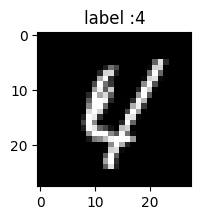

In [12]:
# 첫번쨰 이미지 출력
plt.figure(figsize = (2,2))
i = 700 # i in range(60000)
plt.imshow(X_train[i], cmap='gray')
plt.title("label :"+ str(y_train[i]))
plt.show()

In [5]:
# fetch 계열(패키지 내에 데이터가 없고 인터넷 연결 시 다운로드)
from sklearn.datasets  import fetch_openml
# mnist data fetch : mnist, iris, boston fashion_mnist ...
mnist = fetch_openml(name = 'mnist_784', version = 1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype('int')
X.shape, y.shape

((70000, 784), (70000,))

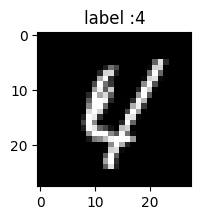

In [21]:
# type(mnist)
# 첫번쨰 이미지 출력
plt.figure(figsize = (2,2))
i = 700 # i in range(60000)
plt.imshow(X[i].reshape(28,-1), cmap='gray')
plt.title("label :"+ str(y[i]))
plt.show()

# 2절. 분류분석의 종류
- predict()
- 크게 2종으로 분류 : 확률적 모델, 판별함수 모델
    * 확률적 모델 : 타겟변수의 확률을 확인이 가능. 확률함수 사용
    * 판별함수 모델 : 타겟함수만 보여줌. 확률로 접근하는 것이 아니라 조건에 따라 체크하는 함수를 사용. 그래프에 선을 그어서 체크한다고 이해(그래프와의 거리가 지표로 작용 가능)
## 2-1. 확률적 모형
    - 주어진 데이터의 각 클래스별 정답일 확률을 계산
    - predict_proba() : 각 분류 클래스별 확률을 알려줌(일부의 판별함수 모델도 존재함)
    - predict_log_proba() : 확률의 로그값을 알려줌
### 1) 확률적 생성 모형
    - 각 클래스별 특징데이터의 확률 분포 추정(베이즈 정리를 사용). 소량의 데이터로도 작동
    - eg) Quadratic Discriminant Analysis, 나이브 베이지안(NaiveBayes)...
### 2) 확률적 판별 모형
    - 확률을 계산하는 함수(판별식) 이용
    - eg) 의사결정나무, 로지스틱 회귀(이진분류)분석   
## 2-2. 판별함수 모형
    - 주어진 데이터를 클래스에 따라 서로 다른 영역으로 나누는 경계면을 찾은 후 그 경계면으로부터 어느 위치에 있는 지를 계산하는 판별 함수를 이용
    - decision_function()
    - eg) 퍼셉트론, 서포트 벡터 머신, MLP(신경망)
    
=> RandomForest, LGBM, XGBoost, CatBoost 등의 앙상블 모형이 더 많이 쓰임

# 3절. 분류 모형 1. 확률적 생성 모형
- 베이즈 정리를 사용하여 확률 분포를 계산

## 3-1. QDA(Quadratic Discriminant Avalysis)
- x가 연속형 데이터(x type float)이면서 정규 분포라고 가정함

In [6]:
# 샘플 데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_features=2, # 독립변수 개수
                          n_informative=2, # 타겟변수에 영향을 주는 독립변수 개수
                          n_redundant= 0, # 타겟변수에 영향을 주지 않는 변수, noise
                          n_clusters_per_class= 1, # 각 클래스 별 서브그룹 수
                          n_classes=2, # 타겟변수 class 수
                          n_samples=100, # 데이터 갯수(행수. 기본값)
                          random_state=9, # random.seed 통일
                          ) 
X.shape, y.shape

((100, 2), (100,))

In [7]:
import numpy as np
np.unique(y)
np.sum(y)

50

In [60]:
# y = 1인 데이터
X[y == 1].shape

(50, 2)

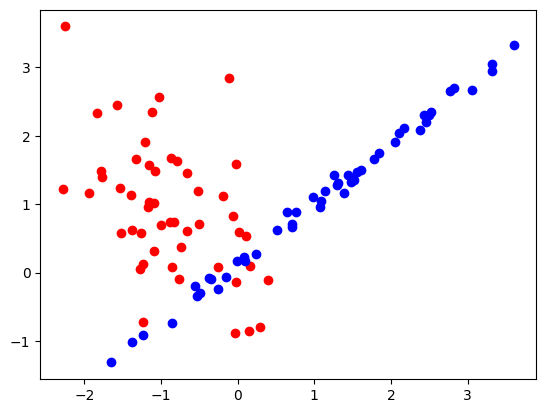

In [61]:
plt.scatter(X[y==0,0],X[y==0,1],c='r')
plt.scatter(X[y==1,0],X[y==1,1],c='b')
plt.show()

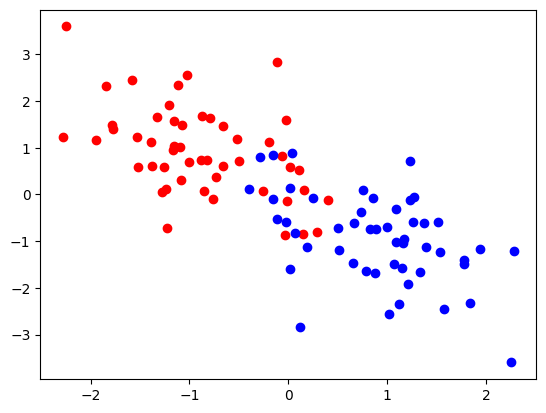

In [62]:
# (0,0) 대칭 구조
X[y==1] = -X[y==0]
plt.scatter(X[y==0,0],X[y==0,1],c='r')
plt.scatter(X[y==1,0],X[y==1,1],c='b')
plt.show()

In [8]:
# QDA 
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model = QuadraticDiscriminantAnalysis()
model.fit(X,y)

QuadraticDiscriminantAnalysis()

In [51]:
x = [[5,5]] # 2차원 데이터 predict
model.predict(x)
p = model.predict_proba(x)
print(p) # 0으로 분류 될 확률, 1로 분류 될 확률

[[8.84215536e-06 9.99991158e-01]]


In [52]:
model.classes_ # 분류될 내용

array([0, 1])

In [9]:
import pandas as pd
y_hat = model.predict(X)
pd.crosstab(y, y_hat)

col_0,0,1
row_0,,
0,48,2
1,0,50


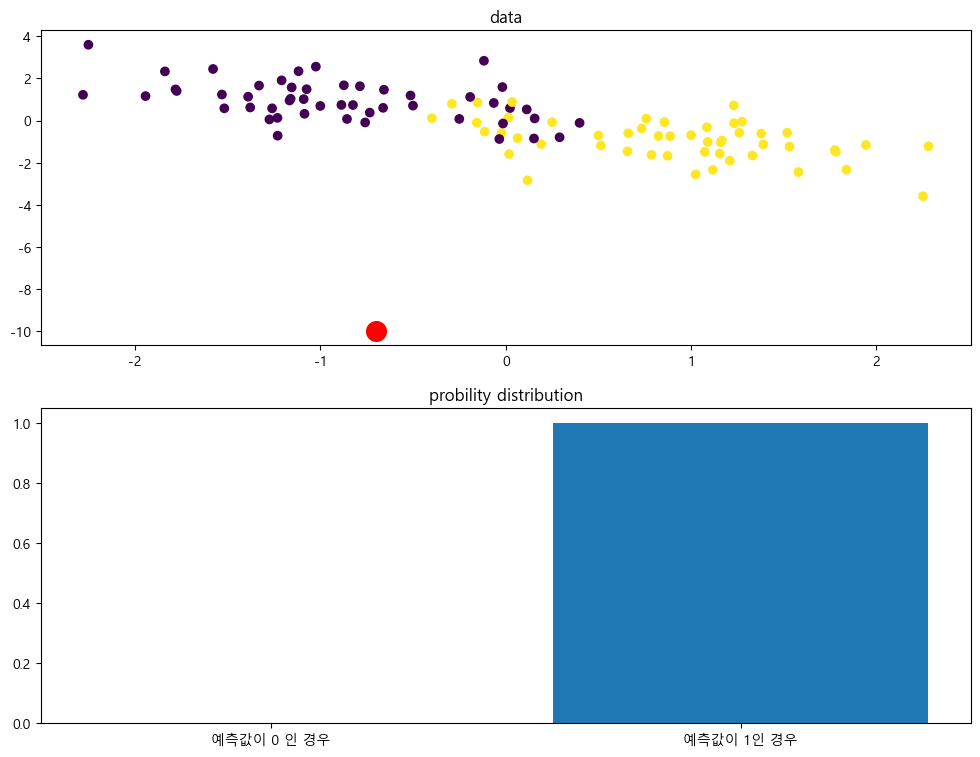

In [89]:
plt.rc('font', family = "Malgun Gothic")
plt.rc('axes', unicode_minus=False)
x = [[-0.7,-10]]
plt.figure(figsize=(12,9))
p = model.predict_proba(x)
plt.subplot(2,1,1) # 2행 1열 그래프 중 첫번째 그래프
plt.scatter(x = X[:,0], y = X[:,1], c= y)
plt.scatter(x[0][0], x[0][1], c='r',s=200)
plt.title('data')

plt.subplot(2,1,2) # 2행 1열 그래프 중 두번째 그래프
plt.bar(model.classes_, p[0])
plt.title('probility distribution')
plt.xticks(model.classes_,["예측값이 0 인 경우", "예측값이 1인 경우"])
plt.show()

In [72]:
model.predict(x)

array([0])

## 3-2. 나이브베이지안 모형

In [10]:
# 데이터
import seaborn as sns
iris = sns.load_dataset('iris')
X = iris.iloc[:,:-1].values
y = iris.iloc[:,-1].values # 범주형(문자) - 라벨인코딩 없이 적용

# 모형 생성
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X,y)

MultinomialNB()

In [109]:
test_X = np.array([[5.1,3.5,1.4,0.2]]) # X.loc[0]
print(model.classes_)
print("test_X의 예측 :",model.predict(test_X)) # 학습 데이터의 타입(DataFrame, np.array) 맞춰주기
print("test_X의 예측 확률:",model.predict_proba(test_X))

['setosa' 'versicolor' 'virginica']
test_X의 예측 : ['setosa']
test_X의 예측 확률: [[0.75199536 0.16092948 0.08707516]]


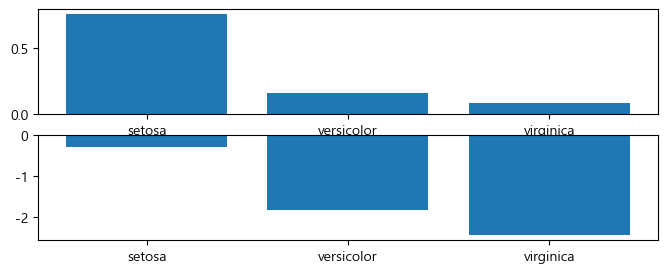

In [113]:
test_X = np.array([[5.1,3.5,1.4,0.2]]) # X.loc[0]
plt.figure(figsize=(8,3))
plt.subplot(2,1,1)
plt.bar(model.classes_, model.predict_proba(test_X)[0])
plt.subplot(2,1,2)
plt.bar(model.classes_, model.predict_log_proba(test_X)[0]) # 로그 확률값 => 차이를 명확하게 보기 좋음. log(0.01) 형태 => 음의 방향으로 전환되며 그래프가 반전대칭
plt.show()

# 4절. 분류모형 2. 확률적 판별 모형
## 4-1 로지스틱 회귀분석

In [17]:
# data
X, y = make_classification(n_features=1,# 독립변수 개수
                           n_informative=1, # 타겟변수에 영향을 주는 독립변수 개수
                           n_redundant=0, # 타겟변수에 영향을 미치지 않는 독립변수 개수
                           n_classes=2,
                           n_samples=100, # 데이터 수
                           random_state=1,
                           n_clusters_per_class = 1, # 각 클래스의 서브 클래스 기본값 2
                          )
X.shape, y.shape

((100, 1), (100,))

In [18]:
np.unique(y),y.sum()

(array([0, 1]), 50)

In [19]:
# 모형
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X,y)

LogisticRegression()

In [20]:
X[0] # -1.65902848
model.predict([X[0]])
# y[0]

array([0])

In [21]:
import numpy as np
xx = np.linspace(-3, 3, 100) # -3 부터 3까지 같은 간격의 100개 데이터
# xx.shape (100,) => xx의 행축 증가 필요
test_x = xx.reshape(-1,1)
test_x = np.expand_dims(xx,axis=-1)
test_x = xx[:,np.newaxis]
test_X = xx[:,None]
y_hat = model.predict(test_x)
prob = model.predict_proba(test_x)
prob1 = prob[:,1] # 1로 분류될 확률
prob0 = prob[:,0] # 0으로 분류될 확률

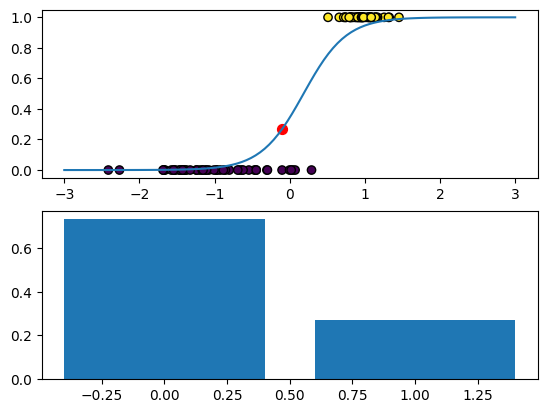

In [22]:
plt.subplot(2,1,1)
x = [[-0.1]]
prob_x = model.predict_proba(x)
plt.scatter(X,y, c=y, edgecolors='k')
plt.plot(xx, prob1) # sigmoid 그래프와 동일한 구조!
plt.scatter(x[0][0],prob_x[0][1], c='r',s=50)

plt.subplot(2,1,2)
plt.bar(model.classes_, prob_x[0])
plt.show()

## 4.2 의사결정나무
- **★ 종속변수에 영향을 주는 독립변수의 범주를 찾는 목적**

In [56]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.get('data')[:,2:] # idx = 2번째, 3번째 열만 
y = data.get('target')
feature_names = [name[:-5] for name in data.feature_names[2:]]
y_label = data.get('target_names')
print(feature_names)

# 모형 생성
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion='entropy', # 분류 품질 기준
                                 max_depth=1,
                                 random_state=1000)
dt_model.fit(X,y) # depth가 1이라 성능이 좋지 않을 예정

['petal length', 'petal width']


DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=1000)

In [57]:
print(X[100]) #X[0], X[50], X[100]
test_x = [[6,  2.5]]
print('예측값 :',dt_model.predict(test_x))
print(dt_model.classes_)
print(dt_model.predict_proba(test_x))

[6.  2.5]
예측값 : [1]
[0 1 2]
[[0.  0.5 0.5]]


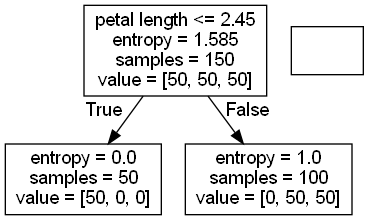

In [58]:
import os
import io
from sklearn.tree import export_graphviz
import pydot
from IPython.core.display import Image

def draw_decision_tree(model, feature_names):
    dot_buf = io.StringIO()
    export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
    graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
    image = graph.create_png()
    return Image(image)

draw_decision_tree(dt_model, feature_names=feature_names)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

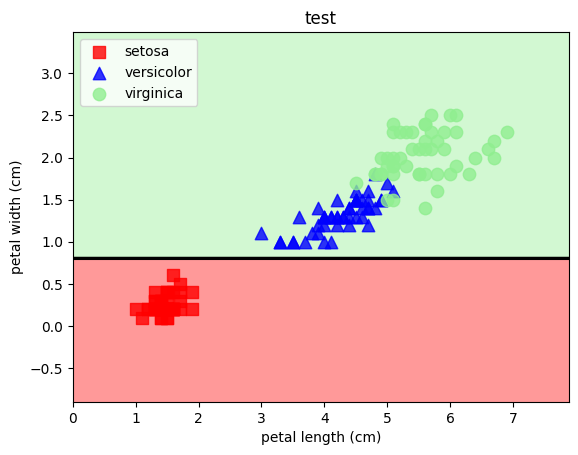

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_decision_regions(X, y, model, title):
    species = ['setosa', 'versicolor', 'virginica']
    resolution = 0.01
    markers = ('s', '^', 'o')
    colors = ('red', 'blue', 'lightgreen')
    cmap = mpl.colors.ListedColormap(colors)
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    Z = model.predict(
    np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    plt.contour(xx1, xx2, Z, cmap=mpl.colors.ListedColormap(['k']))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,
                    c=[cmap(idx)], marker=markers[idx], s=80, label=species[cl])
    plt.xlabel(data.feature_names[2])
    plt.ylabel(data.feature_names[3])
    plt.legend(loc='upper left')
    plt.title(title)
    return Z

plot_decision_regions(X,y,dt_model, 'test')

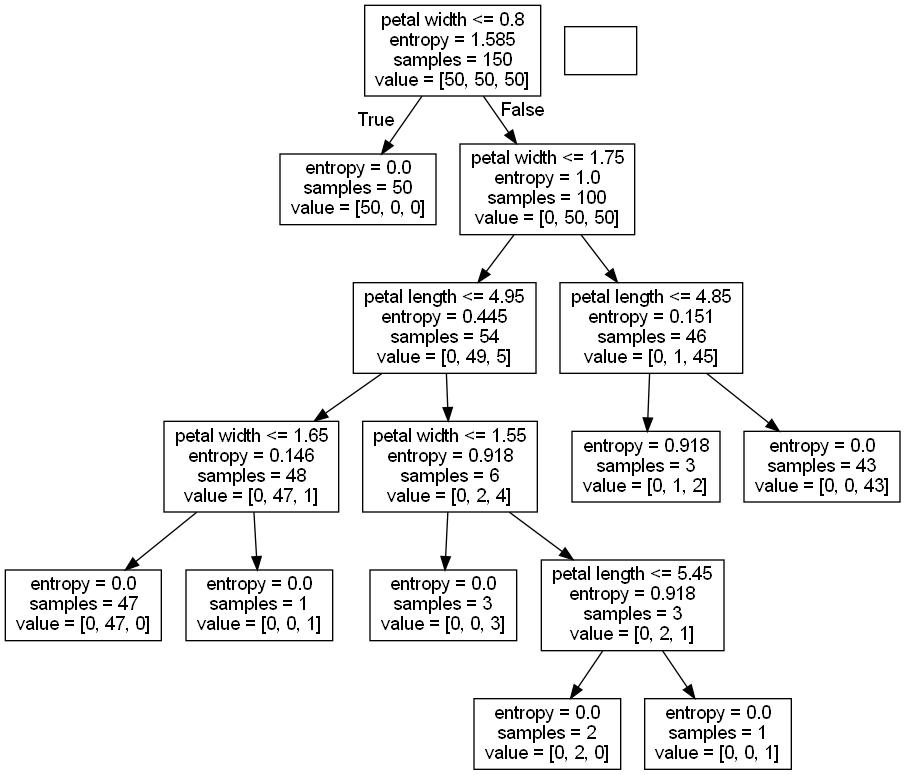

In [59]:
dt_model5 = DecisionTreeClassifier(criterion='entropy',
                                  max_depth=50,
                                   random_state=0
                                  )
dt_model5.fit(X,y)
draw_decision_tree(dt_model5, feature_names=feature_names)

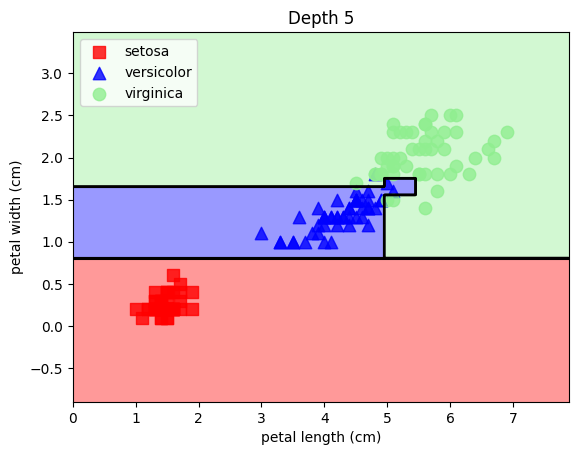

In [60]:
plot_decision_regions(X,y,dt_model5,"Depth 5")
plt.show()

In [61]:
pred = dt_model5.predict(X)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# 5절. 분류모형 3. 판별함수 모형
- SVM : 과거 앙상블 모형이 나오기 전까지는 실세, 퍼셉트론, MLP(predict_proba() 있음), .... 
- predict_proba() 함수 대신 decision_function()을 주력으로 활용

## 5.1 SVM의 SVC

In [76]:
# 데이터 체크
from sklearn.datasets import load_iris
iris = load_iris() # DataFrame
idx = pd.Series(iris.target).isin([0,2])
print(idx.tolist())

X = iris.data[idx]
y = iris.target[idx]
X.shape, y.shape

[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


((100, 4), (100,))

In [77]:
from sklearn.svm import SVC
model = SVC()
model.fit(X,y)

SVC()

In [78]:
y_hat = model.predict(X)
pd.crosstab(y, y_hat)

col_0,0,2
row_0,,
0,50,0
2,0,50


In [83]:
model.decision_function([X[0]]) # 0에 가까운 값일 수록 그룹을 나누는 경계에 가깝다는 의미를 가짐

array([-1.14828042])

## 5.2 퍼셉트론

In [85]:
from sklearn.linear_model import Perceptron
model = Perceptron(max_iter=100, # 학습횟수 epoch 100회
                   random_state=1,
                   eta0=0.1 # learning_rate 지정 가능(lr)
                  )
model.fit(X,y)

Perceptron(eta0=0.1, max_iter=100, random_state=1)

In [86]:
y_hat = model.predict(X)
pd.crosstab(y,y_hat)

col_0,0,2
row_0,,
0,50,0
2,0,50


In [89]:
x = [X[0]]
pred = model.predict(x)
df = model.decision_function(x)
print('예측값 :',pred)
print('판별함수 결과 :',df)

예측값 : [0]
판별함수 결과 : [-0.601]


## 5.3 다중 퍼셉트론(인공신경망)
- predict, decision function, predict_proba, predict_log_proba
- DNN의 축소판

In [90]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(50,50,30),
                   max_iter =500,
                   activation = 'relu')
mlp.fit(X,y)
y_hat = model.predict(X)
pd.crosstab(y,y_hat)

col_0,0,2
row_0,,
0,50,0
2,0,50


# 6절. 분류모형 성능평가
- 혼동행렬(교차표)
- score 함수(f1, recall, precision, accuracy 등...) => fbeta_score
- ROC커브 - roc 커브 영역 확인
- ex. 두 모형이 혼동행렬이 같은 경우

## 6-1 혼동행렬(교차표)

In [102]:
from sklearn.metrics import recall_score, f1_score, fbeta_score, precision_score, confusion_matrix, accuracy_score
y_true = [1,1,0,0,2,1,0,2,2] # 실제값
y_pred = [1,1,0,1,1,0,0,2,1] # 예측값
# 혼동행렬
confusion_matrix(y_true, y_pred) # 그룹이 2개 일 때

array([[2, 1, 0],
       [1, 2, 0],
       [0, 2, 1]], dtype=int64)

In [93]:
pd.crosstab(y_true, y_pred, rownames=['실제값'], colnames=['예측값']) # 그룹이 3개 이상일 때 

예측값,0,1,2
실제값,,,
0,2,1,0
1,1,2,0
2,0,2,1


## 6-2. 혼동행렬을 이용한 평가
- 각종 score() 함수

In [96]:
result = pd.read_csv('data/model_result.csv') # 보험사기자 실제값과 예측값
result.isnull().sum() # 결측치 X

CUST_ID    0
y_true     0
y_pred     0
dtype: int64

In [97]:
result.shape

(1793, 3)

In [99]:
result[result['y_true']==1]
result['y_true'].value_counts()

0    1635
1     158
Name: y_true, dtype: int64

In [101]:
pd.crosstab(result['y_true'],result['y_pred'],margins=True, rownames=['실제값'],colnames=['예측값']) # margins => 합계출력

예측값,0,1,All
실제값,,,
0,1613,22,1635
1,81,77,158
All,1694,99,1793


In [115]:
# 정확도 : 전체 중 맞춘 확률
print( '정확도 :', accuracy_score(result.y_true, result.y_pred))
# recall : 실제 positive 중 맞게 예측한 확률
print('재현율 :',recall_score(result.y_true, result.y_pred))
# precision : positive로 예측한 것 중에 맞게 예측한 확률
print("정밀도 :", precision_score(result.y_true, result.y_pred))
# f1
print("f1 :",f1_score(result.y_true, result.y_pred))
# 특이도(specigicty) : 실제 negative 중에 negitive라고 맞게 예측한 확률
print('특이도 :',recall_score(result.y_true, result.y_pred,pos_label=0))
# 위양성율(fprate) : FN/(TN+FP) : 실제 negative -> positive로 예측한 확률
# 함수 없음
fbeta_score(result.y_true, result.y_pred, beta=1, # beta = 1 : precision 동일. recall과 precision의 비중을 같게
           )

정확도 : 0.9425543781372002
재현율 : 0.4873417721518987
정밀도 : 0.7777777777777778
f1 : 0.5992217898832685
특이도 : 0.9865443425076452


0.7777777777777778

In [120]:
fbeta_score(result.y_true, result.y_pred, beta=2, # beta = 2 : recall의 가중치를 높게, precision 비중을 낮게, 보통 0 ~ 2 사이 수 활용
           )

0.5266757865937073

## 6-3. ROC 커브를 이용한 성능 비교
- ROC그래프의 가로축 위양성율 (fprate : False Positive rate), 세로축 recall값
- AUC가 높아야(그래프 아래 면적이 넓을 때) 좋은 모델

In [129]:
from sklearn.datasets import make_classification
X,y = make_classification(weights=[0.95,0.05], # 0 50%, 1 50% => 0.95 . 0.05 데이터 비중 설정 가능
                         n_samples=1000,
                         random_state=5)
X.shape, y.shape

((1000, 20), (1000,))

In [130]:
np.unique(y)
y.mean()

0.057

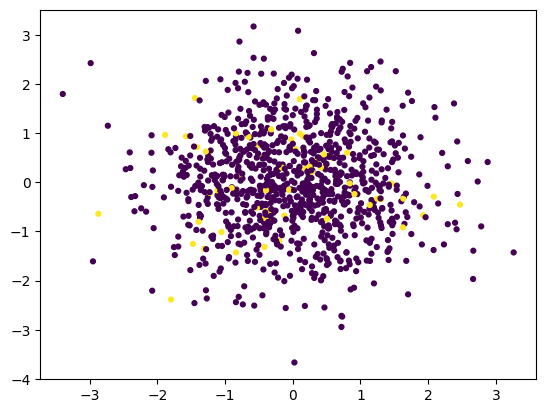

In [136]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1], c = y, s= 12)
plt.show()

In [138]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X,y)

LogisticRegression(random_state=0)

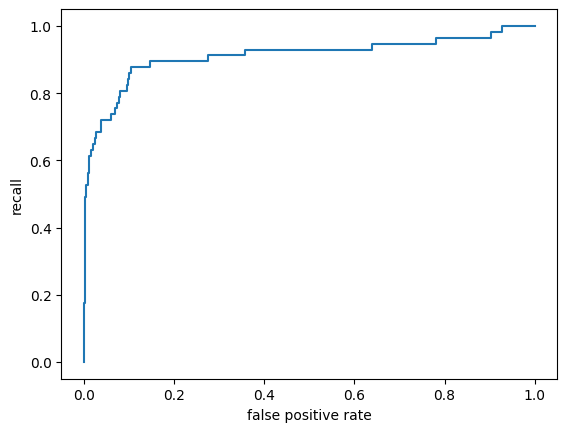

In [147]:
from sklearn.metrics import roc_curve
fpr1, tpr1, thr1 = roc_curve(y, model.decision_function(X))
plt.plot(fpr1, tpr1)
plt.xlabel('false positive rate')
plt.ylabel('recall')
plt.show()

In [141]:
from sklearn.metrics import auc
auc(fpr1, tpr1)

0.9112202563673234

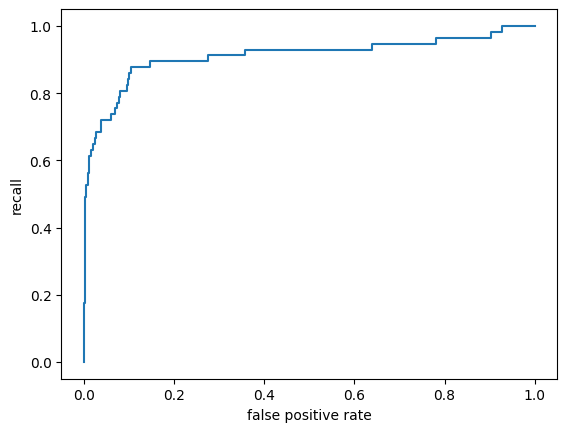

In [155]:
y_proba = model.predict_proba(X)[:,1]
from sklearn.metrics import roc_curve
fpr2, tpr2, thr2 = roc_curve(y, y_proba)
plt.plot(fpr2, tpr2)
plt.xlabel('false positive rate')
plt.ylabel('recall')
plt.show()

## 6-4. 두 모형의 혼동 행렬이 같은 경우(roc_curve 사용)

In [156]:
from sklearn.datasets import make_classification
X,y = make_classification(weights=[0.95,0.05], # 0 50%, 1 50% => 0.95 . 0.05 데이터 비중 설정 가능
                         n_samples=1000,
                         random_state=5)

In [162]:
from sklearn.svm import SVC
model1 = LogisticRegression().fit(X,y)
model2 = SVC(
    gamma= 0.0001, # 함수의 경계선이 부드러워짐
    C = 3000, # C값이 클수록 과적합을 신경쓰지 않아도 된다 / 오차 허용 범위
    probability= True
).fit(X,y)

In [163]:
y_hat1 = model1.predict(X)
y_hat2 = model2.predict(X)

In [164]:
display(pd.crosstab(y,y_hat1, rownames=['실제값'], colnames=['예측값']))
display(pd.crosstab(y,y_hat2, rownames=['실제값'], colnames=['예측값']))

예측값,0,1
실제값,,
0,940,3
1,30,27


예측값,0,1
실제값,,
0,940,3
1,30,27


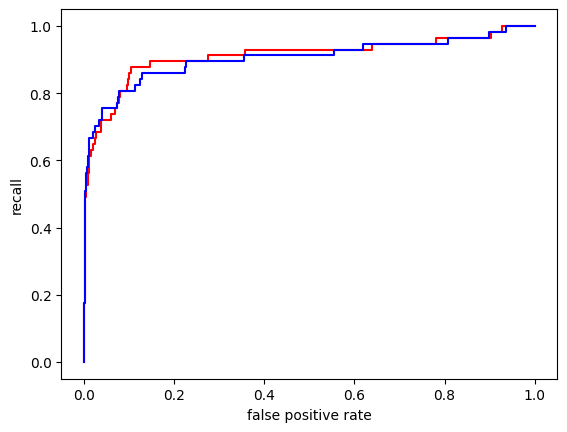

In [166]:
# 혼동행렬이 동일하면 score의 값이 같아짐 => 이 경우 ROC커브를 그려서 체크
fpr1, tpr1, th1 = roc_curve(y, model1.decision_function(X))
fpr2, tpr2, th2 = roc_curve(y, model2.decision_function(X))
plt.plot(fpr1, tpr1, color='r')
plt.plot(fpr2, tpr2, color='b')
plt.xlabel('false positive rate')
plt.ylabel('recall')
plt.show()

In [167]:
# AUC : Area Under Curve : roc커브 아랫부분의 영역
# AUC = 1 : 완벽한 모델
# AUC < 0.5 : 최악의 모델
# AUC = 0.5 : 동전던지기(반만 맞출 수 있음)
from sklearn.metrics import auc
auc(fpr1, tpr1,), auc(fpr2, tpr2)

(0.9112202563673234, 0.9037227214377407)

# 연습문제

In [175]:
# data check
df = pd.read_csv('data/wine.csv')
# df.isnull().sum() # 결측치 X
df.describe(include='all')

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,0D280/0D315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [181]:
# X, y 데이터 분리
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [182]:
# QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model1 = QuadraticDiscriminantAnalysis()
model1.fit(X,y)

QuadraticDiscriminantAnalysis()

In [187]:
model1.predict([X.iloc[0]])

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [191]:
from sklearn.naive_bayes import MultinomialNB
model2 = MultinomialNB()
model2.fit(X,y)

MultinomialNB()

In [192]:
model2.predict([X.iloc[0]])

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [193]:
from sklearn.tree import DecisionTreeClassifier
model3 = DecisionTreeClassifier(criterion='entropy', # 분류 품질 기준
                                 max_depth=1,
                                 random_state=1000)
model3.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=1000)

In [194]:
model3.predict([X.iloc[0]])

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [197]:
from sklearn.linear_model import LogisticRegression
model4 = LogisticRegression(max_iter=500)
model4.fit(X,y)

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500)

In [198]:
model4.predict([X.iloc[0]])

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [199]:
y_hat1 = model1.predict(X)
y_hat2 = model2.predict(X)
y_hat3 = model3.predict(X)
y_hat4 = model4.predict(X)

In [211]:
for i,y_pred in enumerate([y_hat1, y_hat2, y_hat3, y_hat4]) :
    # 정확도 : 전체 중 맞춘 확률
    print( i,'정확도 :', accuracy_score(y, y_pred))
    # recall : 실제 positive 중 맞게 예측한 확률
    print(i,'재현율 :',recall_score(y, y_pred,average='weighted'))
    # precision : positive로 예측한 것 중에 맞게 예측한 확률
    print(i,"정밀도 :", precision_score(y, y_pred,average='weighted'))
    # f1
    print(i,"f1 :",f1_score(y, y_pred,average='weighted'))
    # 특이도(specigicty) : 실제 negative 중에 negitive라고 맞게 예측한 확률
    print(i, '특이도 :',recall_score(y, y_pred,pos_label=0,average='weighted'))
    # 위양성율(fprate) : FN/(TN+FP) : 실제 negative -> positive로 예측한 확률
    # 함수 없음
    print(' ')

0 정확도 : 0.9943820224719101
0 재현율 : 0.9943820224719101
0 정밀도 : 0.9944756554307115
0 f1 : 0.994385705513379
0 특이도 : 0.9943820224719101
 
1 정확도 : 0.8707865168539326
1 재현율 : 0.8707865168539326
1 정밀도 : 0.8725568879237088
1 f1 : 0.8712572722831639
1 특이도 : 0.8707865168539326
 
2 정확도 : 0.601123595505618
2 재현율 : 0.601123595505618
2 정밀도 : 0.37735905063053826
2 f1 : 0.45884138333576535
2 특이도 : 0.601123595505618
 
3 정확도 : 0.9775280898876404
3 재현율 : 0.9775280898876404
3 정밀도 : 0.9779898414652917
3 f1 : 0.9775872831374575
3 특이도 : 0.9775280898876404
 


C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\metrics\_classification.py:1396: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\metrics\_classification.py:1396: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\metrics\_classification.py:1396: UserWarning: Note that